In [98]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
pip install goatools

In [99]:
import sys
import os
sys.path.append(os.path.abspath("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main"))

from Scripts_Imane import features
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import SpectralBiclustering
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.metrics import consensus_score
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.linear_model import LassoCV
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score
import ast, re


### Preparing the GO terms file text -----> csv

In [30]:
# ======== Creating csv from txt file GO annotations ========
txt_file = "/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Go_kegg_path_panther_annot.txt"
csv_file = "/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Go_kegg_path_panther_annot.csv"
df = pd.read_csv(txt_file, sep=None, engine="python", dtype=str)
if df.shape[1] == 1:
    df = pd.read_csv(txt_file, sep=",", header=None, dtype=str, engine="python")
    df.columns = [
        "Gene Name","Transcript Name","KEGG ID","PFAM ID","Pathway ID","Pathway Description",
        "GO ID","GO Description","Panther ID","Panther Description","Description"
    ]
df.to_csv(csv_file, index=False)
print(df.shape)

(77040, 17)


### Adding GO terms, panther ID, pathway desc etc to main file
add_GO_old uses original file found on  github

add_GO(data,'/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Go_kegg_path_panther_annot.csv')  adds GO, Kegg, and everything else see Scripts/features.py

In [122]:
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/paired_mutant_shrvar_zscore.csv')
data = features.add_GO(data, "/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Go_kegg_path_panther_annot.csv")
data.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/paired_mutant_shrvar_zscore_GO.csv', index=False)

### Spectral biclustering 
Just groups dense submatrices (assuming X is ~diagonal per bloc, suboptimal but nice to get an idea)

We later do hierarchical biclustering

Prints also nmber of genes per nb of go terms

In [38]:
### Biclustering

def to_go_list(x):
    if isinstance(x, list):
        return [g for g in x if pd.notna(g)]
    if isinstance(x, str):
        return [g for g in x.split() if g]  
    return []
data['GO'] = data['GO'].apply(to_go_list)

data['n_GO_per_gene'] = data['GO'].apply(len)
n_go_per_gene = data[['mutated_genes', 'n_GO_per_gene']]

all_go = set()
_ = data['GO'].apply(all_go.update)
n_go_total = len(all_go)

print(f"# gènes = {data['mutated_genes'].nunique()}")
print(f"# GO terms distincts = {n_go_total}")

exploded = data[['mutated_genes', 'GO']].explode('GO').dropna()
X = pd.crosstab(exploded['mutated_genes'], exploded['GO']).astype(np.int8)

MIN_GENES_PER_GO = 0
keep_go = (X.sum(axis=0) >= MIN_GENES_PER_GO)  #axis=0 for columns
X = X.loc[:, keep_go]

print(f"# GO terms après filtre (≥{MIN_GENES_PER_GO} gènes) = {X.shape[1]}")

gene_to_go = data[['mutated_genes', 'GO']].drop_duplicates('mutated_genes')
def to_go_list(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        return x.split()
    return []
gene_to_go['GO'] = gene_to_go['GO'].apply(to_go_list)
gene_to_go['n_GO'] = gene_to_go['GO'].apply(len)
go_dist = gene_to_go['n_GO'].value_counts().sort_index()
print(f"# gènes uniques = {gene_to_go.shape[0]}")
go_dist_df = go_dist.reset_index()
go_dist_df.columns = ['n_GO_terms', 'n_genes']
print(go_dist_df.head(20))

N_GENE_CLUSTERS = 8
N_GO_CLUSTERS = 8

model = SpectralBiclustering(
    n_clusters=(N_GENE_CLUSTERS, N_GO_CLUSTERS),
    random_state=0
)
model.fit(X)

gene_labels = pd.Series(model.row_labels_, index=X.index, name='gene_cluster')
go_labels   = pd.Series(model.column_labels_, index=X.columns, name='go_cluster')

row_order = np.argsort(model.row_labels_)
col_order = np.argsort(model.column_labels_)
X_ordered = X.iloc[row_order, col_order]

gene_cluster_table = gene_labels.to_frame().reset_index(names='mutated_genes')
go_cluster_table   = go_labels.to_frame().reset_index(names='GO')

# plt.figure(figsize=(8, 6))
# plt.imshow(X_ordered, aspect='auto', interpolation='nearest')
# plt.title('Biclustering (X réordonnée)')
# plt.xlabel('GO (réordonné)')
# plt.ylabel('Gènes (réordonné)')
# plt.colorbar(label='Présence GO')
# plt.tight_layout()
# plt.show()

def get_block_members(g_cluster, go_cluster):
    rows = gene_labels[gene_labels == g_cluster].index
    cols = go_labels[go_labels == go_cluster].index
    return rows.tolist(), cols.tolist()

k = N_GENE_CLUSTERS
rows = gene_labels[gene_labels == k].index  
cols = go_labels[go_labels == k].index  
print(f"Bicluster {k}: {len(rows)} genes, {len(cols)} GO terms")
print("Genes:", rows[:10].tolist())   # print first 10
print("GO terms:", cols[:10].tolist())
for k in range(model.n_clusters[0]):
    rows = gene_labels[gene_labels == k].index
    cols = go_labels[go_labels == k].index
    print(f"\nBicluster {k}: {len(rows)} genes, {len(cols)} GO terms")
    print("Genes (first 100):", rows[:100].tolist())
    print("GO terms (first 10):", cols[:10].tolist())

# gènes = 589
# GO terms distincts = 351
# GO terms après filtre (≥0 gènes) = 344
# gènes uniques = 589
   n_GO_terms  n_genes
0           1      329
1           2       60
2           3       74
3           4       68
4           5       35
5           6       14
6           7        5
7           8        3
8          10        1
Bicluster 8: 0 genes, 0 GO terms
Genes: []
GO terms: []

Bicluster 0: 272 genes, 18 GO terms
Genes (first 100): ['Cre01.g000650', 'Cre01.g007700', 'Cre01.g007737', 'Cre01.g007901', 'Cre01.g009700', 'Cre01.g010250', 'Cre01.g010864', 'Cre01.g011901', 'Cre01.g012150', 'Cre01.g012650', 'Cre01.g012850', 'Cre01.g015200', 'Cre01.g016556', 'Cre01.g017200', 'Cre01.g018700', 'Cre01.g019500', 'Cre01.g019550', 'Cre01.g019750', 'Cre01.g022650', 'Cre01.g023050', 'Cre01.g025450', 'Cre01.g025500', 'Cre01.g034150', 'Cre01.g036050', 'Cre01.g036100', 'Cre01.g038151', 'Cre01.g038850', 'Cre01.g039550', 'Cre01.g047500', 'Cre01.g049950', 'Cre01.g055000', 'Cre02.g076200', 'Cre02.g0

In [39]:

# fit two models with different cluster numbers
model1 = SpectralBiclustering(n_clusters=(5,5), random_state=0).fit(X)
model2 = SpectralBiclustering(n_clusters=(10,10), random_state=0).fit(X)

score = consensus_score(model1.biclusters_, model2.biclusters_)
print("Consensus score:", score)


Consensus score: 0.1482679187504218


### How many genes have which features
comment out depending on the annotations available

In [ ]:
# Stats of how many features
df = data
df_gene = df.groupby('mutated_genes', as_index=False).agg({
    'GO': lambda x: sum([xi if isinstance(xi, list) else [] for xi in x], []),
    'Pathway Description': lambda x: sum([xi if isinstance(xi, list) else [] for xi in x], []),
    'Panther ID': lambda x: sum([xi if isinstance(xi, list) else [] for xi in x], []),
    #'KEGG ID' : lambda x: sum([xi if isinstance(xi, list) else [] for xi in x], [])
})

def has_nonempty(x):
    return isinstance(x, list) and len([v for v in x if str(v).strip() != ""]) > 0

df_gene['has_GO']      = df_gene['GO'].apply(has_nonempty)
df_gene['has_pathway'] = df_gene['Pathway Description'].apply(has_nonempty)
df_gene['has_panther'] = df_gene['Panther ID'].apply(has_nonempty)
#df_gene['has_kegg'] = df_gene['KEGG ID'].apply(has_nonempty)

total_genes  = df_gene.shape[0]
with_GO      = df_gene['has_GO'].sum()
with_pathway = df_gene['has_pathway'].sum()
with_panther = df_gene['has_panther'].sum()
with_kegg = df_gene['has_kegg'].sum()
with_any     = ((df_gene['has_GO']) | (df_gene['has_pathway']) | (df_gene['has_panther']) ).sum()

print(f"Total unique genes: {total_genes}")
print(f"Genes with GO: {with_GO}")
print(f"Genes with Pathway Description: {with_pathway}")
print(f"Genes with Panther ID: {with_panther}")
print(f"Genes with KEGG: {with_kegg}")
print(f"Genes with at least one (GO or Pathway or Panther): {with_any}")

### Predictive power of GO
regression setup (GO features → predict phenotype PCs)

In [24]:
### predictive power of GO terms
data = data[~(data['light_regime']=='20h_ML')]
data = data[~(data['mutated_genes']=='WT')]
def make_X_from_GO(df, gene_col='mutated_genes', go_col='GO', min_genes_per_go=3):
    g = df[[gene_col, go_col]].dropna(subset=[gene_col]).copy()
    def to_list(x):
        if isinstance(x, list): vals = x
        elif pd.isna(x): return []
        else:
            s = str(x).strip()
            try:
                v = ast.literal_eval(s)
                vals = list(v) if isinstance(v, (list, tuple)) else [s]
            except Exception:
                s = s.strip('[]()').replace('&', ',').replace('|', ',')
                vals = re.split(r'[,\s;]+', s)
        out = []
        for t in vals:
            t = str(t).strip().strip("'\"")
            if not t: continue
            t = t.replace('Go:', 'GO:').replace('GO: ', 'GO:')
            m = re.match(r'^GO:\s*(\d+)$', t)
            if m:
                t = f"GO:{int(m.group(1)):07d}"
                out.append(t)
        return list(dict.fromkeys(out))  # dedup, order-preserving
    g[go_col] = g[go_col].apply(to_list)
    expl = g.explode(go_col).dropna(subset=[go_col])
    X = pd.crosstab(expl[gene_col], expl[go_col]).astype(np.uint8)
    if min_genes_per_go and min_genes_per_go > 1:
        keep = X.sum(axis=0) >= min_genes_per_go
        X = X.loc[:, keep]
    return X

X = make_X_from_GO(data, min_genes_per_go=3)
Y = data.pivot_table(index='mutated_genes', columns='light_regime',
                   values='y2_slope', aggfunc='mean')
print(X.shape,Y.shape)
Y = Y.fillna(0)
Y = Y.replace([np.inf, -np.inf], 0)
genes = X.index.intersection(Y.index)
X = X.loc[genes]
Y = Y.loc[genes]
X = X.loc[:, X.sum(axis=0) > 0]
scaler_Y = StandardScaler()
Y_scaled = scaler_Y.fit_transform(Y.values)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_pcs = 7  # number of PCs you want
pca = PCA(n_components=n_pcs)
PC_scores = pca.fit_transform(Y_scaled)
PC_df = pd.DataFrame(PC_scores,
                     index=Y.index,
                     columns=[f"PC{i+1}" for i in range(n_pcs)])
PC_mat = PC_df.loc[X.index].to_numpy()
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))
rmse_scorer = make_scorer(rmse, greater_is_better=False)
results = {}
for pc in range(7):
    y = PC_mat[:, pc]
    model = LassoCV(alphas=np.logspace(-2, 2, 60),max_iter=50000, tol=1e-3, selection='cyclic')
    y_pred = cross_val_predict(model, X_scaled, y, cv=5)
    Rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2   = r2_score(y, y_pred)
    norm_rmse = Rmse / np.std(y)  # relative error
    results[f"PC{pc+1}"] = {
        "RMSE": Rmse,
        "Normalized_RMSE": norm_rmse,
        "R2": r2
    }

print(results)

(344, 275) (588, 7)


{'PC1': {'RMSE': np.float64(2.1674508363893694), 'Normalized_RMSE': np.float64(1.0067576346673015), 'R2': -0.013560934960899829}, 'PC2': {'RMSE': np.float64(0.9392277482067349), 'Normalized_RMSE': np.float64(1.0154490736312756), 'R2': -0.0311368211386156}, 'PC3': {'RMSE': np.float64(0.7308104241432322), 'Normalized_RMSE': np.float64(1.0013475517035362), 'R2': -0.0026969193026662452}, 'PC4': {'RMSE': np.float64(0.5937577815848233), 'Normalized_RMSE': np.float64(1.0036209875733682), 'R2': -0.007255086697742774}, 'PC5': {'RMSE': np.float64(0.5136319571936999), 'Normalized_RMSE': np.float64(1.0059341916464768), 'R2': -0.01190359792345097}, 'PC6': {'RMSE': np.float64(0.460346814537359), 'Normalized_RMSE': np.float64(1.0053822840987408), 'R2': -0.010793537179601076}, 'PC7': {'RMSE': np.float64(0.39756030898074474), 'Normalized_RMSE': np.float64(1.005037225742437), 'R2': -0.010099825128054185}}


## Aggregate the GOs

In [129]:
import requests
from goatools.obo_parser import GODag
from collections import defaultdict
from collections import defaultdict
import re
import ast

GO_PAT = re.compile(r'^GO:\d{7}$')

def parse_go(value):
    if isinstance(value, list):
        items = value
    elif isinstance(value, str):
        s = value.strip()
        if (s.startswith('[') and s.endswith(']')) or (s.startswith('(') and s.endswith(')')):
            try:
                items = ast.literal_eval(s)
                if not isinstance(items, (list, tuple)):
                    items = [s]
            except Exception:
                items = [s]
        else:
            s = s.replace(';', ',').replace('|', ',')
            s = re.sub(r'\s+', ',', s)
            items = [t for t in (x.strip() for x in s.split(',')) if t]
    else:
        items = []
    seen, out = set(), []
    for it in items:
        it = str(it).strip()
        if GO_PAT.match(it) and it not in seen:
            seen.add(it)
            out.append(it)
    return out

df_mutants_gene_go = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Bayesian_splitgenes_latest_phase2(5.18)_GO_phytosome.csv')
df_mutants_gene_go['GO'] = df_mutants_gene_go['GO'].apply(parse_go)
obo_url = "http://purl.obolibrary.org/obo/go/go.obo"
obo_file = "go.obo"
response = requests.get(obo_url)
with open(obo_file, 'wb') as file:
    file.write(response.content)
go_dag = GODag(obo_file)

go_to_mutants = defaultdict(set)
for _, row in df_mutants_gene_go.iterrows():
    mutant = row['mutated_genes']
    for go_term in row['GO']:
        go_to_mutants[go_term].add(mutant)

# Function to get parent GO terms, handling missing terms
def get_parent_go_terms(go_term, go_dag):
    if go_term in go_dag:
        return go_dag[go_term].parents
    return set()

# Aggregate mutants at different GO levels, 1st part keeps only parents with>= min_genes, 2nd part keeps all parents and children
def aggregate_mutants_at_level(go_to_mutants, go_dag, min_mutants=10):
    # current_level = go_to_mutants.copy()
    # while True:
    #     next_level = defaultdict(set)
    #     for go_term, mutants in current_level.items():
    #         #next_level[go_term].update(mutants) 
    #         if len(mutants) < min_mutants:
    #             for parent in get_parent_go_terms(go_term, go_dag):
    #                 next_level[parent.id].update(mutants)
    #         else:
    #             next_level[go_term].update(mutants)
    #     if all(len(mutants) >= min_mutants for mutants in next_level.values()):
    #         return next_level
    #     if not next_level:
    #         break
    #     current_level = next_level
    # return current_level
    counts = {go: len(ms) for go, ms in go_to_mutants.items()}
    out = defaultdict(set)
    for go, muts in go_to_mutants.items():
        out[go].update(muts)  # keep child
        if counts.get(go, 0) < min_mutants:
            if go in go_dag:
                for p in go_dag[go].get_all_parents():
                    out[p].update(muts)
    return out

aggregated_go_to_mutants = aggregate_mutants_at_level(go_to_mutants, go_dag, min_mutants=20)
for go_term, mutants in aggregated_go_to_mutants.items():
    print(f"{go_term}: {len(mutants)} mutants")

go.obo: fmt(1.2) rel(2025-07-22) 43,230 Terms
GO:0006355: 7 mutants
GO:2001141: 7 mutants
GO:0019219: 7 mutants
GO:0019222: 8 mutants
GO:0008150: 114 mutants
GO:0080090: 7 mutants
GO:0010468: 8 mutants
GO:0051252: 7 mutants
GO:0065007: 24 mutants
GO:0050794: 24 mutants
GO:0060255: 8 mutants
GO:0050789: 24 mutants
GO:0010556: 8 mutants
GO:0009889: 8 mutants
GO:0043565: 3 mutants
GO:0003674: 191 mutants
GO:0003676: 22 mutants
GO:0005488: 82 mutants
GO:0003677: 11 mutants
GO:0016887: 19 mutants
GO:0016462: 22 mutants
GO:0016787: 46 mutants
GO:0017111: 22 mutants
GO:0016817: 22 mutants
GO:0003824: 112 mutants
GO:0016818: 22 mutants
GO:0004672: 48 mutants
GO:0004713: 44 mutants
GO:0005524: 76 mutants
GO:0006468: 48 mutants
GO:0003779: 1 mutants
GO:0008092: 6 mutants
GO:0005515: 78 mutants
GO:0016020: 34 mutants
GO:0140662: 1 mutants
GO:0140657: 17 mutants
GO:0044183: 1 mutants
GO:0004114: 2 mutants
GO:0042578: 3 mutants
GO:0016788: 6 mutants
GO:0004112: 2 mutants
GO:0008081: 2 mutants
GO:00

### Adding Aggregated_GO column to the dataset (df_out)

In [130]:
print("Number of aggregated GO terms:", len(aggregated_go_to_mutants))
#### adding a column of aggregated GOs to the original DataFrame
# df_mutants_gene_go : original DataFrame with 'mutant_ID' and 'GO' columns
# aggregated_go_to_mutants : dict {GO_term : set_of_mutants}
mut_to_aggGO = {}
for go_term, mutants in aggregated_go_to_mutants.items():
    for m in mutants:
        mut_to_aggGO.setdefault(m, set()).add(go_term)

df_out = df_mutants_gene_go.copy()
df_out['Aggregated_GO'] = df_out['mutated_genes'].map(
    lambda m: list(mut_to_aggGO.get(m, []))
)
print(df_out[['mutated_genes','GO','Aggregated_GO']].head())

Number of aggregated GO terms: 608
   mutated_genes                                                GO  \
0  Cre13.g589400                                                []   
1  Cre13.g589350                          [GO:0006355, GO:0043565]   
2  Cre08.g384320                                      [GO:0016887]   
3  Cre13.g581050                                                []   
4  Cre09.g400849  [GO:0004672, GO:0004713, GO:0005524, GO:0006468]   

                                       Aggregated_GO  
0                                                 []  
1  [GO:0019222, GO:0003677, GO:0010468, GO:000635...  
2  [GO:0016787, GO:0003674, GO:0017111, GO:001646...  
3                                                 []  
4   [GO:0006468, GO:0005524, GO:0004672, GO:0004713]  


### Predictive power of GO/Aggregated_GO (scores per pc too)

(324, 608) matrix
Aggregated_GO  GO:0000139  GO:0000160  GO:0000166  GO:0000226  GO:0000271  \
mutated_genes                                                               
Cre01.g000650           0           0           0           0           0   
Cre01.g001200           0           0           0           0           0   
Cre01.g001800           0           0           0           0           0   
Cre01.g007700           0           0           0           0           0   
Cre01.g007901           0           0           0           0           0   

Aggregated_GO  GO:0000375  GO:0000377  GO:0000398  GO:0000413  GO:0000796  \
mutated_genes                                                               
Cre01.g000650           0           0           0           0           0   
Cre01.g001200           0           0           0           0           0   
Cre01.g001800           0           0           0           0           0   
Cre01.g007700           0           0           0        

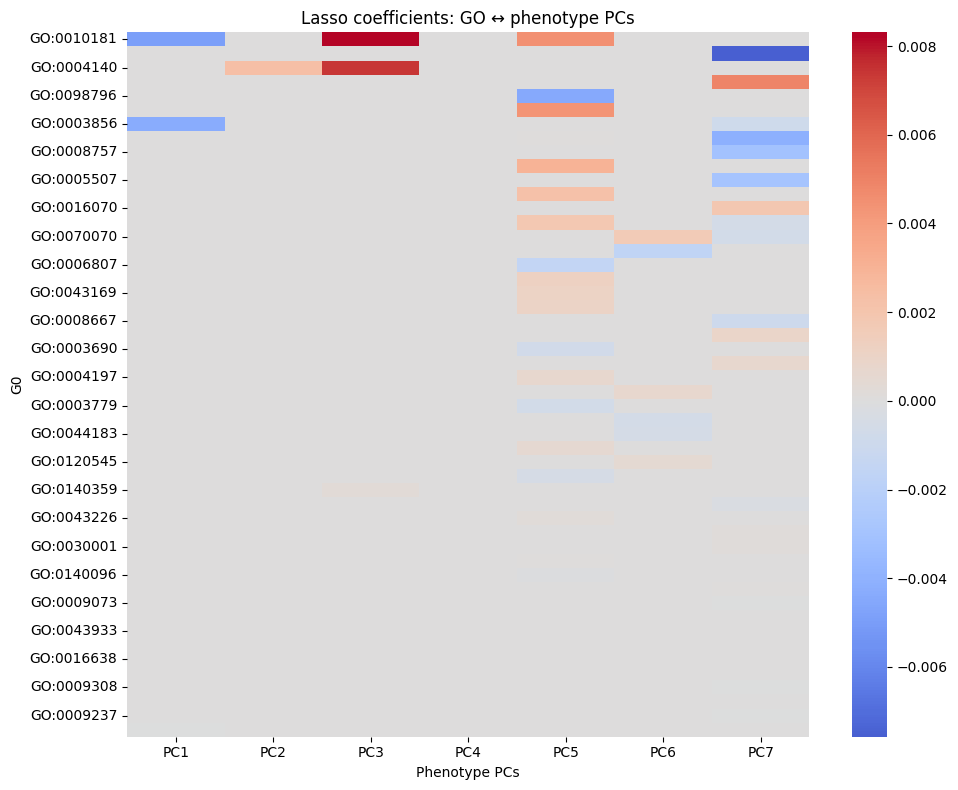

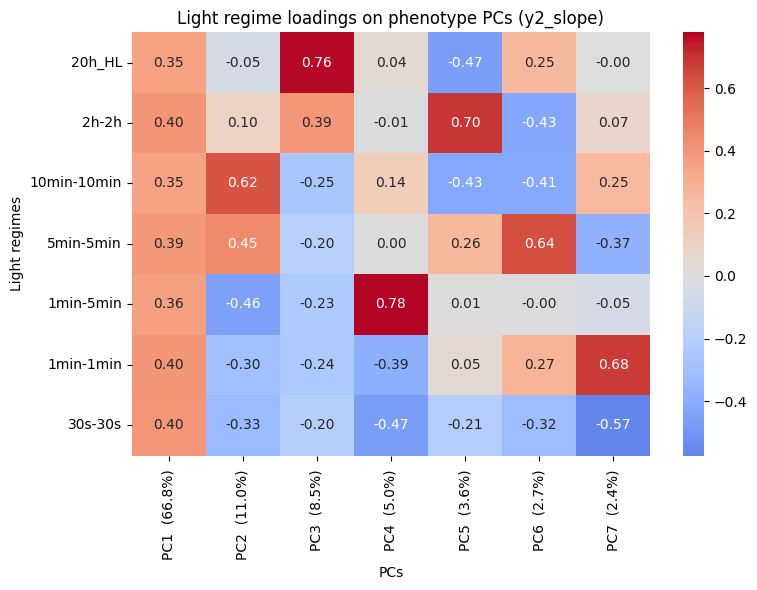

In [137]:
### Creating a binary matrix of aggregated Gos
import pandas as pd
rows = []
for go_term, mutants in aggregated_go_to_mutants.items():
    for m in mutants:
        rows.append((m, go_term))
df_long = pd.DataFrame(rows, columns=['mutated_genes', 'Aggregated_GO'])
# pivot to binary matrix mutant × GO 
df_binary = pd.crosstab(df_long['mutated_genes'], df_long['Aggregated_GO']).astype(int)
print(df_binary.shape, "matrix")
print(df_binary.head())

#### Running PCA + Lasso with aggregated GO terms
df = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Bayesian_splitgenes_latest_phase2(5.18)_GO_phytosome.csv')
df = df[~(df['mutant_ID']== 'WT')]
df = df[df['mutated_genes'].notna() & df['mutant_ID'].notna()]
df = df[~(df['light_regime'].isin(['20h_ML']))]
X = df_binary
df = df[df['mutant_ID'].notna() & df['mutated_genes'].notna()]
Y = df.pivot_table(index='mutated_genes', columns='light_regime',
                   values='y2_slope', aggfunc='mean')
print(X.shape, Y.shape)
Y = Y.replace([np.inf, -np.inf], 0)
Y = Y
common = X.index.intersection(Y.index)
print(len(common), "mutants communs")
X = df_binary   # or use X from above
X = X.loc[common]
Y = Y.loc[common]
Y = Y.fillna(0)                 
X = X.loc[:, X.var() > 0]       
yscaler = StandardScaler()
Y_scaled = yscaler.fit_transform(Y)

xscaler = StandardScaler(with_mean=False) # sparse/binary
X_scaled = xscaler.fit_transform(X)

K = 7
pca = PCA(n_components=K)                 # garde toutes les composantes
Y_scores = pca.fit_transform(Y_scaled)       # = Y V (en base standardisée)
Y_white = Y_scores / pca.singular_values_


alphas = None  # laisse LassoCV choisir
lasso_cv_kwargs = dict(cv=5, n_alphas=100)#, alphas=alphas)
U_coefs = []
for k in range(K):
    yk = Y_white[:, k]
    model, model_name = LassoCV(**lasso_cv_kwargs).fit(X_scaled, yk), 'Lasso'
    #model, model_name = RidgeCV(alphas=np.logspace(-4, 4, 100), cv=5).fit(X_scaled, yk), 'Ridge'
    U_coefs.append(model.coef_)

# U: gènes x PCs
U = pd.DataFrame(np.column_stack(U_coefs),
                 index=X.columns,
                 columns=[f"PC{k+1}" for k in range(K)])


explained = pd.Series(pca.explained_variance_ratio_,
                      index=[f"PC{i+1}" for i in range(Y_white.shape[1])])

### Top GOs par PC (by abs value))
# def top_go_for_pc(U, pc, n=15):
#     return U[pc].abs().sort_values(ascending=False).head(n).to_frame("abs_coef").join(U[[pc]])
def top_go_with_desc(U, pc, annotation_file, n=25):
    gi = pd.read_csv(annotation_file, dtype=str)
    meta = (gi[['GO ID','GO Description','Pathway Description', 'Panther Description']]
            .dropna(subset=['GO ID']).drop_duplicates('GO ID').set_index('GO ID'))
    ix = U[pc].abs().nlargest(n).index
    out = pd.DataFrame({'abs_coef': U[pc].abs().loc[ix], 'coef': U[pc].loc[ix]})
    return out.join(meta).sort_values('abs_coef', ascending=False)
# example:
# print(top_go_with_desc(U, 'PC3', annotation_file, n=25))
pc = "PC7"
top_PC = top_go_with_desc(U, pc,'/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Go_kegg_path_panther_annot.csv', n=5)
print(pc, pd.DataFrame(top_PC))


# Sort gos by their strongest coefficient magnitude
go_order = U.abs().max(axis=1).sort_values(ascending=False).index[:50]  # top 50 gos
plt.figure(figsize=(10, 8))
sns.heatmap(U.loc[go_order], cmap='coolwarm', center=0, annot=False)
plt.title(f"{model_name} coefficients: GO ↔ phenotype PCs")
plt.xlabel("Phenotype PCs")
plt.ylabel("G0")
plt.tight_layout()
plt.show()

pca.fit(Y_scaled)
explained_var = pca.explained_variance_ratio_ * 100
loadings = pd.DataFrame(pca.components_.T,
                        index=Y.columns,  # original light regimes
                        columns=[f"PC{i+1}  ({explained_var[i]:.1f}%) " for i in range(pca.n_components_)])
order = ["20h_HL", "2h-2h", "10min-10min", 
         "5min-5min", "1min-5min", "1min-1min", "30s-30s"]
loadings = loadings.loc[order]
plt.figure(figsize=(8, 6))
sns.heatmap(loadings, cmap='coolwarm', center=0, annot=True, fmt=".2f") #.iloc[:, :2]
plt.title("Light regime loadings on phenotype PCs (y2_slope)")
plt.xlabel("PCs")
plt.ylabel("Light regimes")
plt.tight_layout()
plt.show()

### Hierarchical clustering

Après nettoyage: 342 gènes × 275 GO


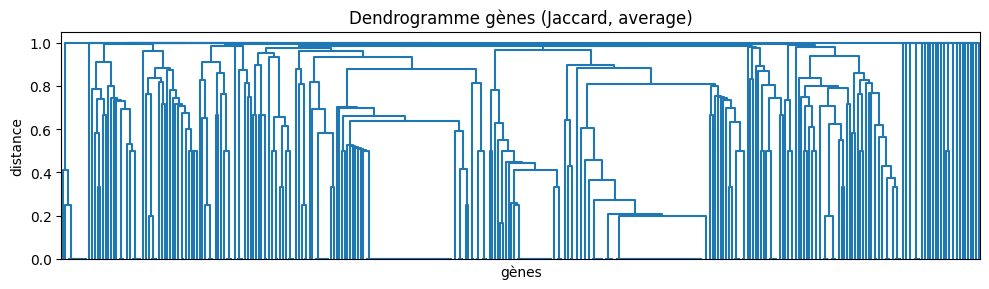

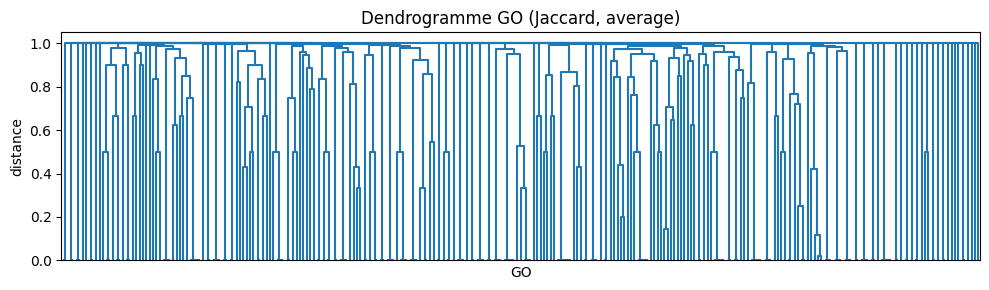


--- Gènes par cluster ---
gene_cluster
0     10
1      6
2     13
3     20
4      1
5      6
6      7
7      6
8      1
9      6
10     9
11     1
12     5
13    10
14    57
15    28
16    68
17     2
18    11
19     1
20     4
21    20
22    19
23     1
24     1
25     2
26     3
27     2
28     2
29     1
30     1
31     1
32     1
33     1
34     1
35     1
36     1
37     1
38     1
39     1
40     1
41     1
42     1
43     1
44     1
45     1
46     1
47     1
48     1
Name: count, dtype: int64

--- GO par cluster ---
go_cluster
0      2
1      2
2      2
3      2
4      6
      ..
105    1
106    1
107    1
108    1
109    1
Name: count, Length: 110, dtype: int64


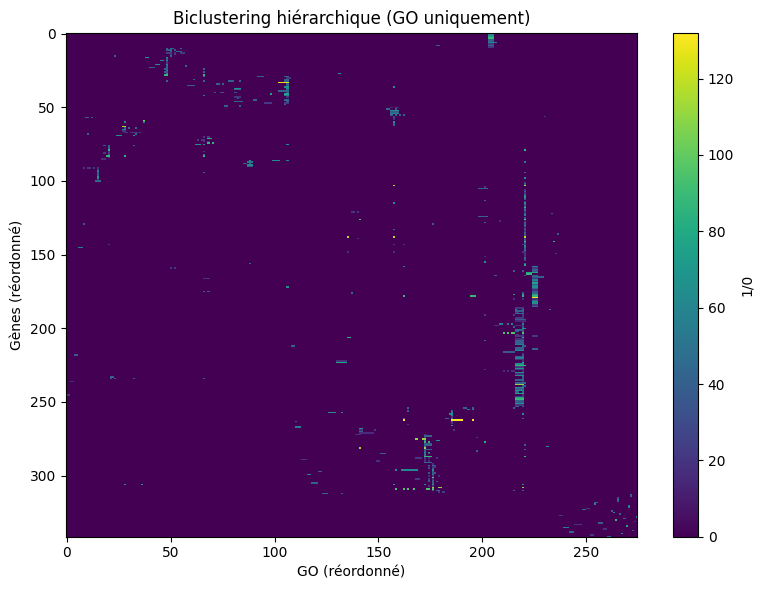

Bicluster (0,0): 10 gènes × 2 GO, densité=0.000
Bicluster (0,1): 10 gènes × 2 GO, densité=0.000
Bicluster (0,2): 10 gènes × 2 GO, densité=0.000
Bicluster (0,3): 10 gènes × 2 GO, densité=0.000
Bicluster (0,4): 10 gènes × 6 GO, densité=0.000
Bicluster (0,5): 10 gènes × 3 GO, densité=0.000
Bicluster (0,6): 10 gènes × 2 GO, densité=0.000
Bicluster (0,7): 10 gènes × 2 GO, densité=0.000
Bicluster (0,8): 10 gènes × 3 GO, densité=0.000
Bicluster (0,9): 10 gènes × 3 GO, densité=0.000
Bicluster (0,10): 10 gènes × 2 GO, densité=0.000
Bicluster (0,11): 10 gènes × 7 GO, densité=0.000
Bicluster (0,12): 10 gènes × 1 GO, densité=0.000
Bicluster (0,13): 10 gènes × 1 GO, densité=0.000
Bicluster (0,14): 10 gènes × 2 GO, densité=0.000
Bicluster (0,15): 10 gènes × 3 GO, densité=0.000
Bicluster (0,16): 10 gènes × 2 GO, densité=0.000
Bicluster (0,17): 10 gènes × 2 GO, densité=0.000
Bicluster (0,18): 10 gènes × 2 GO, densité=0.000
Bicluster (0,19): 10 gènes × 8 GO, densité=0.000
Bicluster (0,20): 10 gènes × 1

In [33]:
#  Jaccard dendogram
#X = df_binary
Xc = X.loc[X.sum(axis=1) > 0, X.sum(axis=0) > 0]
print(f"Après nettoyage: {Xc.shape[0]} gènes × {Xc.shape[1]} GO")

Xb = (Xc.values > 0)
row_dist = pdist(Xb, metric='jaccard')
col_dist = pdist(Xb.T, metric='jaccard')

Z_rows = linkage(row_dist, method='average')
Z_cols = linkage(col_dist, method='average')

plt.figure(figsize=(10, 3))
dendrogram(Z_rows, no_labels=True, color_threshold=0.0)
plt.title("Dendrogramme gènes (Jaccard, average)")
plt.xlabel("gènes"); plt.ylabel("distance")
plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 3))
dendrogram(Z_cols, no_labels=True, color_threshold=0.0)
plt.title("Dendrogramme GO (Jaccard, average)")
plt.xlabel("GO"); plt.ylabel("distance")
plt.tight_layout(); plt.show()

ROW_THRESH = 0.9  
COL_THRESH = 0.9

row_labels = fcluster(Z_rows, ROW_THRESH, criterion='distance') - 1
col_labels = fcluster(Z_cols, COL_THRESH, criterion='distance') - 1
gene_labels = pd.Series(row_labels, index=Xc.index, name='gene_cluster')
go_labels   = pd.Series(col_labels, index=Xc.columns, name='go_cluster')

print("\n--- Gènes par cluster ---")
print(gene_labels.value_counts().sort_index())
print("\n--- GO par cluster ---")
print(go_labels.value_counts().sort_index())

rord = np.argsort(row_labels); cord = np.argsort(col_labels)
X_ordered = Xc.iloc[rord, cord]

plt.figure(figsize=(8,6))
plt.imshow(X_ordered, aspect='auto', interpolation='nearest')
plt.title('Biclustering hiérarchique (GO uniquement)')
plt.xlabel('GO (réordonné)'); plt.ylabel('Gènes (réordonné)')
plt.colorbar(label='1/0'); plt.tight_layout(); plt.show()

def get_block(g_cluster, go_cluster):
    rows = gene_labels[gene_labels == g_cluster].index
    cols = go_labels[go_labels == go_cluster].index
    return rows.tolist(), cols.tolist()

def block_density(rows, cols):
    if len(rows)==0 or len(cols)==0: return np.nan
    sub = Xc.loc[rows, cols].values
    return sub.sum() / (sub.shape[0]*sub.shape[1])

for gk in sorted(gene_labels.unique()):
    for fk in sorted(go_labels.unique()):
        r,c = get_block(gk,fk)
        d = block_density(r,c)
        print(f"Bicluster ({gk},{fk}): {len(r)} gènes × {len(c)} GO, densité={d:.3f}")


##### Differences between Go and aggregated GO

In [41]:
import pandas as pd
import numpy as np
def to_set(x):
    if isinstance(x, list): return set(str(v).strip() for v in x if pd.notna(v) and str(v).strip())
    if pd.isna(x): return set()
    return set(str(x).split())  # fallback

df_cmp = df_out.copy()  # your dataframe with columns 'GO' and 'Aggregated_GO'

df_cmp['GO_set']   = df_cmp['GO'].apply(to_set)
df_cmp['Agg_set']  = df_cmp['Aggregated_GO'].apply(to_set)

df_cmp['same']     = df_cmp['GO_set'] == df_cmp['Agg_set']
df_cmp['GO_only']  = df_cmp.apply(lambda r: sorted(r['GO_set'] - r['Agg_set']), axis=1)
df_cmp['Agg_only'] = df_cmp.apply(lambda r: sorted(r['Agg_set'] - r['GO_set']), axis=1)

# Rows where they differ
diff_rows = df_cmp[~df_cmp['same']][['mutated_genes','GO_only','Agg_only']]
print(f"Equal rows: {df_cmp['same'].sum()} / {len(df_cmp)}")
print("First differences:")
print(diff_rows.head(20).to_string(index=False))


Equal rows: 29680 / 39754
First differences:
mutated_genes GO_only                                                                                                                                                                                                                                                                                                                                                                                                     Agg_only
Cre13.g589350      []                                                                                                                                                                                     [GO:0003674, GO:0003676, GO:0003677, GO:0005488, GO:0008150, GO:0009889, GO:0010468, GO:0010556, GO:0019219, GO:0019222, GO:0050789, GO:0050794, GO:0051252, GO:0060255, GO:0065007, GO:0080090, GO:0140110, GO:2001141]
Cre13.g590600      []                                                                                                

In [126]:
df_out.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/paired_mutant_shrvar_zscore_GO.csv', index=False)

### Go term volcano plots 
paired t test (gene-level) with variance shrinkage

In [49]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests

def gene_level_ttest_with_shrinkage_allregimes(data, gene_col='mutated_genes', slope_col='y2_slope', plate_col='plate'):
    """
    Applies per-gene t-tests across all light regimes, comparing mutant slopes
    to WT means on the same plate, with variance shrinkage toward the global mean.
    """
    data = data.copy()
    regimes = ordered_regimes
    all_genes = []
    all_pvals = []
    all_zscores = []
    all_regimes = []
    all_deltas= []

    # Split WT vs mutant
    wt_df = data[data[gene_col] == 'WT']
    filtered_mutants = data[data[gene_col] != 'WT']

    for regime in regimes:
        mut_sub = filtered_mutants[filtered_mutants['light_regime'] == regime]
        wt_sub = wt_df[wt_df['light_regime'] == regime]

        gene_deltas = {}
        raw_vars = {}

        for gene, group in mut_sub.groupby(gene_col):
            deltas = []
            for _, row in group.iterrows():
                plate = row[plate_col]
                mutant_slope = row[slope_col]
                wt_slopes = wt_sub[wt_sub[plate_col] == plate][slope_col].values

                if len(wt_slopes) < 2:
                    continue

                delta = mutant_slope - np.mean(wt_slopes)
                deltas.append(delta)

            deltas = np.array(deltas)
            if len(deltas) < 2 or np.std(deltas) < 1e-8:
                continue

            gene_deltas[gene] = deltas
            raw_vars[gene] = np.var(deltas, ddof=1)

        if not gene_deltas:
            continue

        # === James–Stein shrinkage toward global mean ===
        var_values = np.array(list(raw_vars.values()))
        global_mean_var = np.mean(var_values)
        tau2 = np.var(var_values)
        B = tau2 / (tau2 + var_values)  # shrinkage weights

        shrinked_vars = {
            gene: B[i] * global_mean_var + (1 - B[i]) * raw_vars[gene]
            for i, gene in enumerate(raw_vars)
        }

        for gene, deltas in gene_deltas.items():
            n = len(deltas)
            mean_delta = np.mean(deltas)
            std = np.sqrt(shrinked_vars[gene])
            se = std / np.sqrt(n)
            t_stat = mean_delta / se
            p_val = 2 * (1 - norm.cdf(abs(t_stat)))
            p_val = max(p_val, 1e-300)
            z_score = np.sign(t_stat) * norm.ppf(1 - p_val / 2)

            all_genes.append(gene)
            all_pvals.append(p_val)
            all_zscores.append(z_score)
            all_regimes.append(regime)
            all_deltas.append(mean_delta)

    # === Compile results ===
    summary = pd.DataFrame({
        'mutated_genes': all_genes,
        'light_regime': all_regimes,
        'zscore': all_zscores,
        'pval': all_pvals,
        'mean_delta': all_deltas

    })

    # Apply FDR correction per light regime
    summary['FDR_gene_ttest'] = summary.groupby('light_regime')['pval'].transform(
        lambda p: multipletests(p, method='fdr_bh')[1]
    )

    # Merge corrected pvals into original dataset
    data = data.merge(
        summary[['mutated_genes', 'light_regime', 'FDR_gene_ttest']],
        on=['mutated_genes', 'light_regime'],
        how='left'
    )

    return data, summary

Aggregated_GO  GO:0000041  GO:0000042  GO:0000079  GO:0000139  GO:0000155  \
mutated_genes                                                               
Cre01.g000650           0           0           0           0           0   
Cre01.g001200           0           0           0           0           0   
Cre01.g001800           0           0           0           0           0   
Cre01.g007700           0           0           0           0           0   
Cre01.g007737           0           0           0           0           0   
...                   ...         ...         ...         ...         ...   
Cre17.g741950           0           0           0           0           0   
Cre17.g745097           0           0           0           0           0   
Cre17.g746397           0           0           0           0           0   
Cre24.g755447           0           0           0           0           0   
Cre24.g755747           0           0           0           0           0   

/tmp/ipykernel_564854/3527433688.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormap, len(go_terms_present))


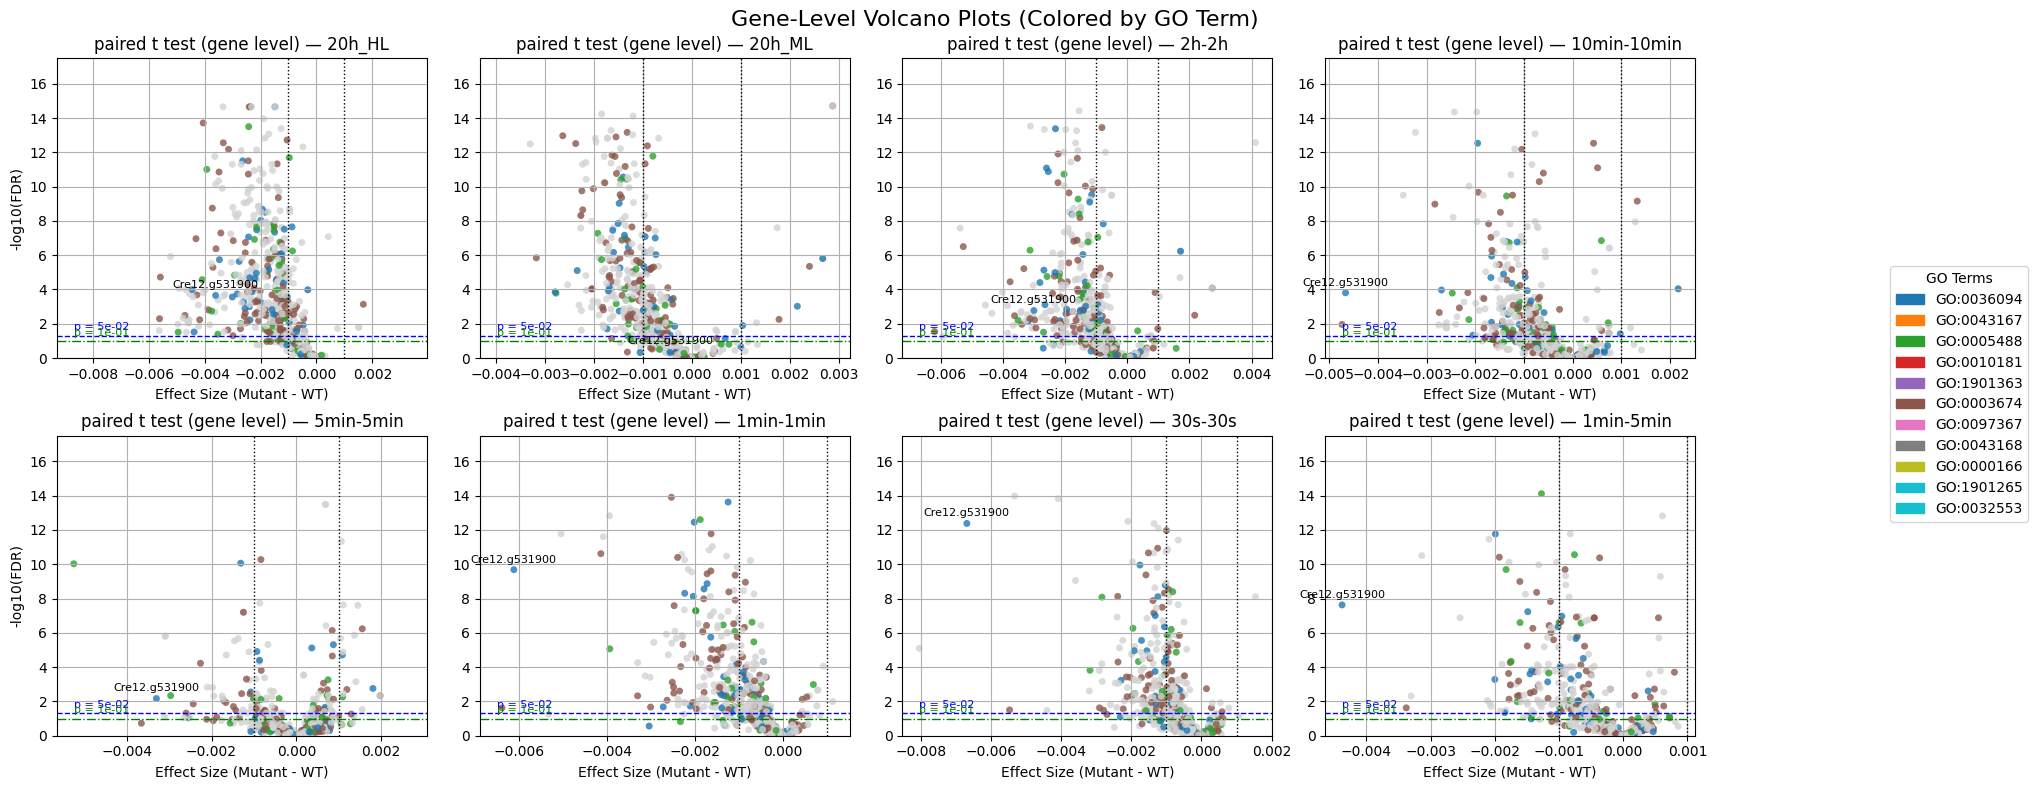

In [133]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import pandas as pd
import numpy as np

def map_gene_colors_from_go_matrix(X, go_terms_to_flag, colormap='tab10'):
    """
    X: binary DataFrame (genes × GO terms)
    go_terms_to_flag: list of GO terms to color
    Returns:
        gene_color_map: dict of gene → color
        go_color_map: dict of GO term → color
    """
    import matplotlib.cm as cm

    X = X.copy()
    # Only keep GO terms of interest
    go_terms_present = [term for term in go_terms_to_flag if term in X.columns]
    X = X.loc[:, go_terms_present]

    # Map colors to GO terms
    cmap = cm.get_cmap(colormap, len(go_terms_present))
    go_color_map = {go: cmap(i) for i, go in enumerate(go_terms_present)}

    # Map each gene to its first matching GO term (from the flagged list)
    gene_color_map = {}
    for gene, row in X.iterrows():
        for go_term in go_terms_present:
            if row[go_term] == 1:
                gene_color_map[gene] = go_color_map[go_term]
                break
        if gene not in gene_color_map:
            gene_color_map[gene] = 'lightgray'

    return gene_color_map, go_color_map
ordered_regimes = [
    '20h_HL', '20h_ML', '2h-2h', '10min-10min',
    '5min-5min', '1min-1min', '30s-30s', '1min-5min'
]
def plot_volcano_grid_by_go(
    gene_stats,
    gene_colors,
    go_color_map,
    fdr_thresholds=(0.05, 0.1),
    delta_threshold=0.001,
    gene_to_annotate='Cre12.g531900'
):
    regimes = ordered_regimes
    n_cols = 4
    n_rows = int(np.ceil(len(regimes) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharex=False, sharey=False)
    axes = axes.flatten()

    for i, regime in enumerate(regimes):
        ax = axes[i]
        df = gene_stats[gene_stats['light_regime'] == regime].copy()
        df['neglog10_fdr'] = -np.log10(df['FDR_gene_ttest'].clip(lower=1e-300))
        df['color'] = df['mutated_genes'].map(gene_colors).fillna('lightgray')

        # Plot each gene
        ax.scatter(df['mean_delta'], df['neglog10_fdr'],
                   color=df['color'], alpha=0.8, s=25, edgecolor='none')

        # Annotate the specific gene if it's present
        gene_row = df[df['mutated_genes'] == gene_to_annotate]
        if not gene_row.empty:
            x = gene_row['mean_delta'].values[0]
            y = gene_row['neglog10_fdr'].values[0]
            ax.text(x, y + 0.3, gene_to_annotate, fontsize=8, ha='center', va='bottom', color='black')

        # FDR threshold lines
        for fdr in fdr_thresholds:
            y_val = -np.log10(fdr)
            style = '--' if fdr == 0.05 else '-.'
            color = 'blue' if fdr == 0.05 else 'green'
            ax.axhline(y_val, linestyle=style, color=color, linewidth=1)
            ax.text(df['mean_delta'].min(), y_val + 0.2,
                    f'p = {fdr:.0e}', color=color, fontsize=8,
                    verticalalignment='bottom')

        # Effect size vertical lines
        if delta_threshold:
            ax.axvline(-delta_threshold, linestyle=':', color='black', linewidth=1)
            ax.axvline(delta_threshold, linestyle=':', color='black', linewidth=1)

        ax.set_title(f'paired t test (gene level) — {regime}')
        ax.set_xlabel('Effect Size (Mutant - WT)')
        if i % n_cols == 0:
            ax.set_ylabel('-log10(FDR)')
        ax.grid(True)
        ax.set_ylim(0, 17.5)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # GO term legend
    legend_handles = [
        mpatches.Patch(color=go_color_map[go], label=go) for go in go_color_map
    ]
    fig.legend(handles=legend_handles, title='GO Terms',
               loc='center right', bbox_to_anchor=(1.02, 0.5))

    plt.tight_layout()
    plt.subplots_adjust(right=0.85, top=0.92)
    plt.suptitle('Gene-Level Volcano Plots (Colored by GO Term)', fontsize=16)
    plt.show()

data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Bayesian_splitgenes_latest_phase2(5.18)_GO.csv')
data_phytosome = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Bayesian_splitgenes_latest_phase2(5.18)_GO_phytosome.csv')
data_drive = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Bayesian_splitgenes_latest_phase2(5.18)_GO_drive.csv')
corrected_data, gene_stats = gene_level_ttest_with_shrinkage_allregimes(data)
#data = data_phytosome
def make_X_from_GO(df, gene_col='mutated_genes', go_col='Aggregated_GO', min_genes_per_go=1):
    import ast, re
    g = df[[gene_col, go_col]].dropna(subset=[gene_col]).copy()
    def to_list(x):
        if isinstance(x, list):
            vals = x
        elif pd.isna(x):
            return []
        else:
            s = str(x).strip()
            try:
                v = ast.literal_eval(s)
                vals = list(v) if isinstance(v, (list, tuple)) else [s]
            except Exception:
                s = s.strip('[]()').replace('&', ',').replace('|', ',')
                vals = re.split(r'[,\s;]+', s)
        out = []
        for t in vals:
            t = str(t).strip().strip("'\"")
            if not t: continue
            t = t.replace('Go:', 'GO:').replace('GO: ', 'GO:')
            m = re.match(r'^GO:\s*(\d+)$', t)
            if m:
                t = f"GO:{int(m.group(1)):07d}"
                out.append(t)
        return list(dict.fromkeys(out))  # dedup
    g[go_col] = g[go_col].apply(to_list)
    expl = g.explode(go_col).dropna(subset=[go_col])
    # Binary presence/absence matrix
    X = pd.crosstab(expl[gene_col], expl[go_col]).clip(upper=1).astype(np.uint8)
    if min_genes_per_go and min_genes_per_go > 1:
        keep = X.sum(axis=0) >= min_genes_per_go
        X = X.loc[:, keep]
    return X

import ast, re
#X = make_X_from_GO(data_drive, min_genes_per_go=1)
X1 = make_X_from_GO(data_phytosome)
X2 = make_X_from_GO(data_drive)

# Union: mark GO terms from both files as present
combined_X = (X1.add(X2, fill_value=0) >= 1).astype(int)
X=combined_X

go_matrix = X
X.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/X.csv')
print(X)
# Step 2: define GO terms to highlight
flagged_go_terms = ['GO:0036094', 'GO:0043167', 'GO:0005488', 'GO:0010181', 'GO:1901363', 'GO:0003674', 'GO:0097367', 'GO:0043168', 'GO:0000166', 'GO:1901265', 'GO:0032553']
missing_terms = [term for term in flagged_go_terms if term not in X.columns]
print("Missing GO terms (not in matrix):", missing_terms)
for term in flagged_go_terms:
    if term in X.columns:
        n_genes = (X[term] == 1).sum()
        print(f"{term}: {n_genes} genes")

# Step 3: compute gene → color
gene_color_map, go_color_map = map_gene_colors_from_go_matrix(X, flagged_go_terms)

# Step 4: plot
plot_volcano_grid_by_go(gene_stats, gene_color_map, go_color_map)


### PC plots GO color coded

/tmp/ipykernel_564854/482813591.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, len(go_terms))


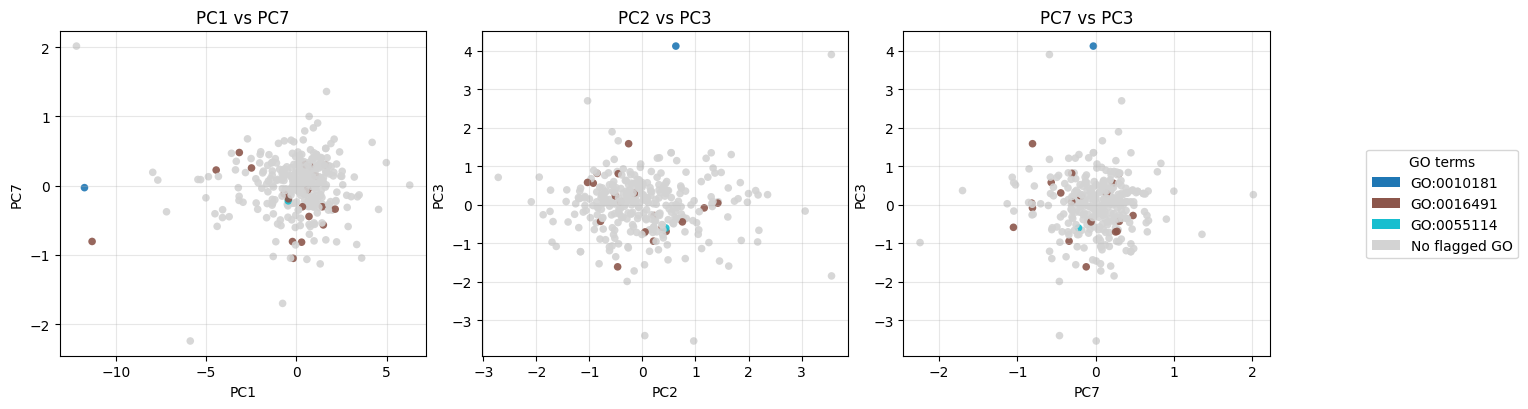

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 1) Align first
common = X.index.intersection(Y.index)
X = X.loc[common]
Y = Y.loc[common]

# 2) PCA on the aligned Y only
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
scaler = StandardScaler()
Y_scaled = scaler.fit_transform(Y.values)

n_pcs = 7
pca = PCA(n_components=n_pcs, random_state=0)
PC_scores = pca.fit_transform(Y_scaled)

# 3) Build Y_scores with the SAME index (now lengths match)
Y_scores = pd.DataFrame(PC_scores, index=Y.index,
                        columns=[f"PC{i+1}" for i in range(n_pcs)])

# Inputs expected:
# - Y_scores: DataFrame (genes × PCs), index = genes (same as X.index), cols like 'PC1','PC2',...
# - X: binary DataFrame (genes × GO terms)
# - flagged_go_terms: list of GO IDs to color (e.g., ['GO:0010181','GO:0016491','GO:0055114'])

from matplotlib import cm
from matplotlib.colors import to_hex

def color_by_go(X, genes_idx, flagged_go_terms, cmap_name='tab10'):
    go_terms = [g for g in flagged_go_terms if g in X.columns]
    cmap = cm.get_cmap(cmap_name, len(go_terms))
    # use hex strings, not RGBA tuples
    go_color_map = {go: to_hex(cmap(i)) for i, go in enumerate(go_terms)}

    gene_colors = pd.Series('lightgray', index=genes_idx, dtype=object)
    for go in go_terms:
        has_go = X.loc[genes_idx, go].astype(bool)
        gene_colors.loc[(gene_colors == 'lightgray') & has_go] = go_color_map[go]
    return gene_colors, go_color_map


def plot_pc_pairs_colored_by_go(Y_scores, X, flagged_go_terms,
                                pc_pairs=(('PC1','PC2'),('PC3','PC3')),
                                s=30, alpha=0.9):
    genes_idx = Y_scores.index.intersection(X.index)
    Ys = Y_scores.loc[genes_idx]
    gene_colors, go_color_map = color_by_go(X, genes_idx, flagged_go_terms)

    n = len(pc_pairs)
    ncols = min(3, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4.2*nrows), squeeze=False)
    axes = axes.ravel()

    for ax, (pcx, pcy) in zip(axes, pc_pairs):
        ax.scatter(Ys[pcx], Ys[pcy], c=gene_colors.loc[genes_idx].values, s=s, alpha=alpha, linewidths=0)
        ax.set_xlabel(pcx); ax.set_ylabel(pcy); ax.grid(True, alpha=0.3)
        ax.set_title(f'{pcx} vs {pcy}')

    # legend for GO terms
    from matplotlib.patches import Patch
    handles = [Patch(facecolor=go_color_map[go], edgecolor='none', label=go) for go in go_color_map]
    handles.append(Patch(facecolor='lightgray', edgecolor='none', label='No flagged GO'))
    if handles:
        fig.legend(handles=handles, title='GO terms', loc='center right', bbox_to_anchor=(1.02, 0.5))
    plt.tight_layout(); plt.subplots_adjust(right=0.85)
    plt.show()

# ---- Example usage ----
flagged_go_terms = ['GO:0010181','GO:0016491','GO:0055114']  # edit
pc_pairs = [('PC1','PC7'), ('PC2','PC3'), ('PC7','PC3')]
plot_pc_pairs_colored_by_go(Y_scores, X, flagged_go_terms, pc_pairs)


/tmp/ipykernel_564854/2377616467.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(unique_gos))


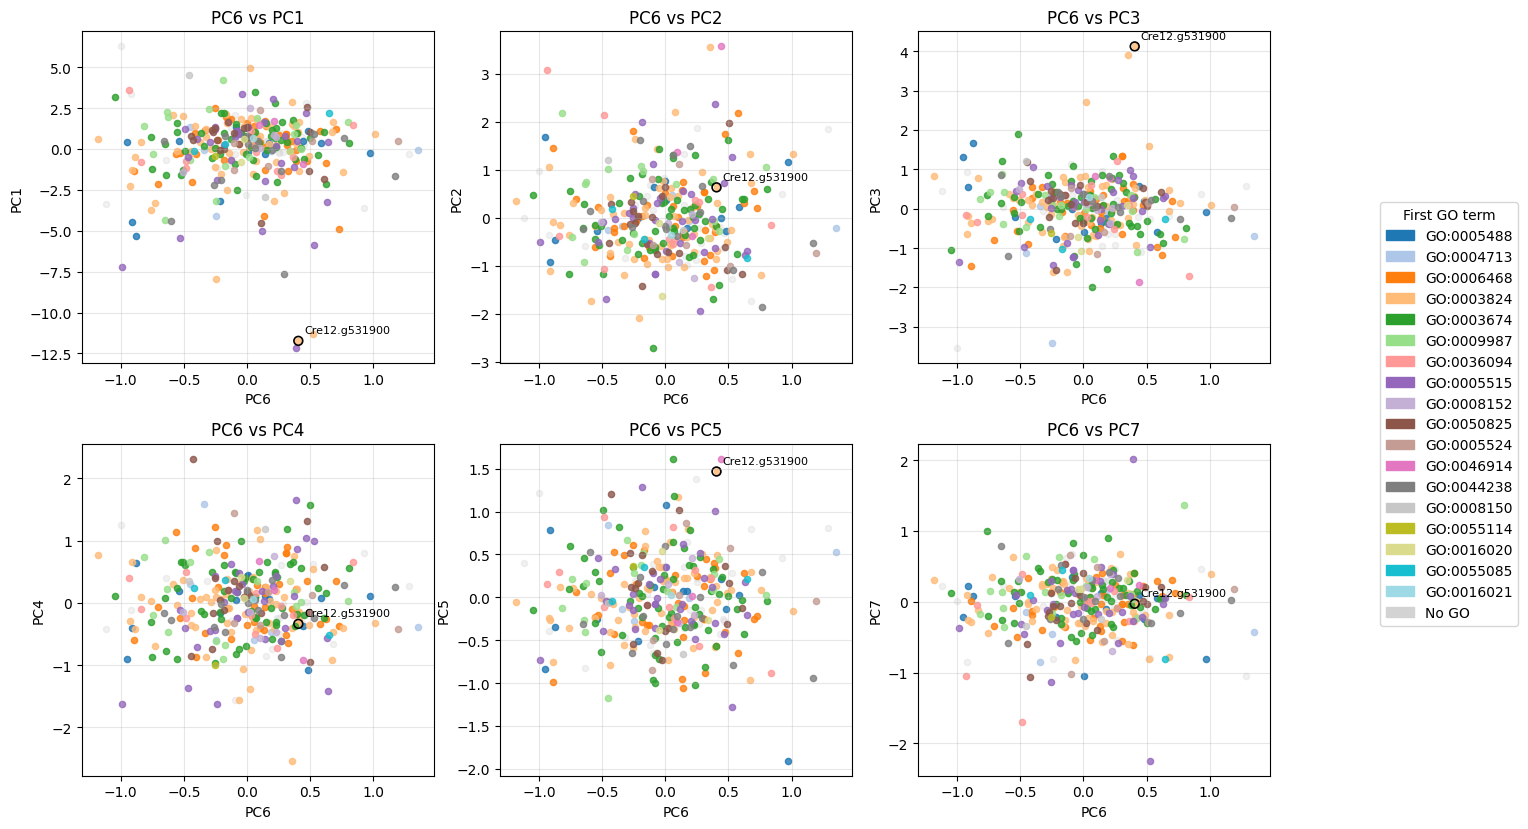

In [149]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import to_hex
from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
data = data_drive
# ---------- STEP 1: PCA ------------
# Align indices
common = X.index.intersection(Y.index)
X = X.loc[common]
Y = Y.loc[common]

# PCA
scaler = StandardScaler()
Y_scaled = scaler.fit_transform(Y.values)

n_pcs = 7
pca = PCA(n_components=n_pcs, random_state=0)
PC_scores = pca.fit_transform(Y_scaled)

Y_scores = pd.DataFrame(PC_scores, index=Y.index, columns=[f"PC{i+1}" for i in range(n_pcs)])

# ---------- STEP 2: Extract FIRST GO term for each gene ----------
def extract_first_GO(df, gene_col='mutated_genes', go_col='Aggregated_GO_min20'):
    df = df.dropna(subset=[gene_col, go_col])
    go_map = {}

    for _, row in df.iterrows():
        gene = row[gene_col]
        raw = row[go_col]
        try:
            if isinstance(raw, list):
                go_list = raw
            elif isinstance(raw, str):
                go_list = eval(raw) if raw.startswith('[') else [raw]
            else:
                go_list = []
        except:
            go_list = []

        for go in go_list:
            go = str(go).strip().upper().replace('GO: ', 'GO:')
            if go.startswith('GO:'):
                go_map[gene] = go
                break

    return pd.Series(go_map)

first_go = extract_first_GO(data)
Y_scores['GO'] = first_go.reindex(Y_scores.index)

# ---------- STEP 3: Assign unique color to each GO ----------
unique_gos = Y_scores['GO'].dropna().unique()
cmap = cm.get_cmap('tab20', len(unique_gos))
go_color_map = {go: to_hex(cmap(i)) for i, go in enumerate(unique_gos)}

Y_scores['color'] = Y_scores['GO'].map(go_color_map).fillna('lightgray')

# ---------- STEP 4: Plot PC pairs with annotated genes ----------
def plot_pc_pairs_by_first_GO(Y_scores, pc_pairs=[('PC1', 'PC2')], s=20, alpha=0.8, highlight_genes=None):
    n = len(pc_pairs)
    ncols = min(3, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.2 * nrows), squeeze=False)
    axes = axes.ravel()

    for ax, (pcx, pcy) in zip(axes, pc_pairs):
        df = Y_scores.copy()
        gray = df[df['color'] == 'lightgray']
        ax.scatter(gray[pcx], gray[pcy], color='lightgray', s=s, alpha=0.3)

        for go, color in go_color_map.items():
            subset = df[df['GO'] == go]
            ax.scatter(subset[pcx], subset[pcy], color=color, s=s, alpha=alpha)

        # Add annotations for specific genes
        if highlight_genes:
            sub = df[df.index.isin(highlight_genes)]
            ax.scatter(sub[pcx], sub[pcy], s=s+20, facecolors='none', edgecolors='black', linewidths=1.2)
            for gene, row in sub.iterrows():
                ax.annotate(gene, (row[pcx], row[pcy]), fontsize=8,
                            xytext=(4, 4), textcoords='offset points',
                            ha='left', va='bottom', color='black')

        ax.set_xlabel(pcx); ax.set_ylabel(pcy)
        ax.set_title(f'{pcx} vs {pcy}')
        ax.grid(True, alpha=0.3)

    # Global legend
    handles = [Patch(color=color, label=go) for go, color in go_color_map.items()]
    handles.append(Patch(color='lightgray', label='No GO'))
    fig.legend(handles=handles, title='First GO term', loc='center right', bbox_to_anchor=(1.02, 0.5))
    plt.tight_layout(); plt.subplots_adjust(right=0.85)
    plt.show()


# --- Example usage ---
highlight_genes = ['Cre12.g531900']  # ← Add more as needed
pc_pairs = [('PC6', 'PC1'), ('PC6','PC2'), ('PC6','PC3'), ('PC6','PC4'), ('PC6','PC5'), ('PC6','PC7')]

plot_pc_pairs_by_first_GO(Y_scores, pc_pairs, highlight_genes=highlight_genes)



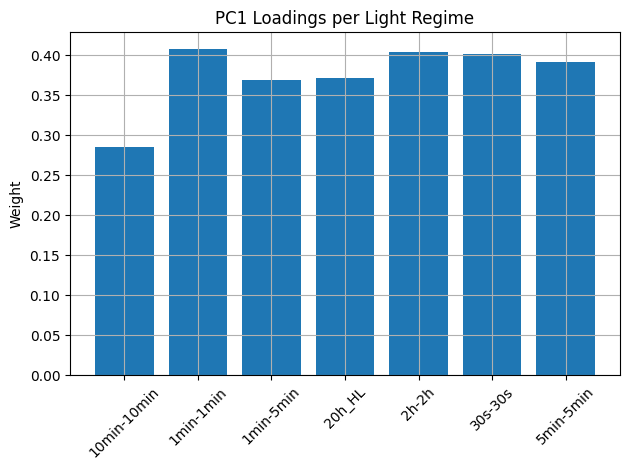

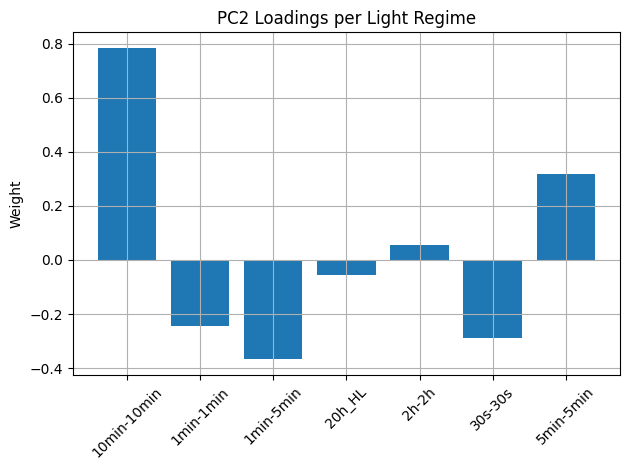

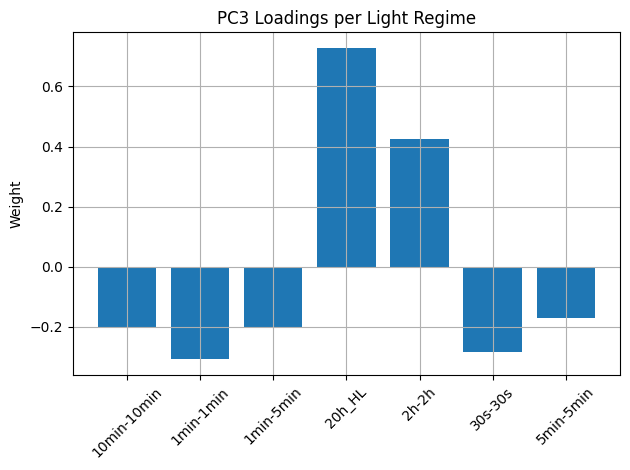

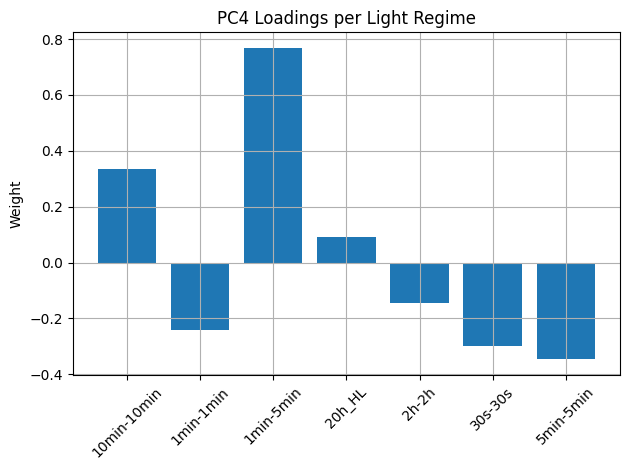

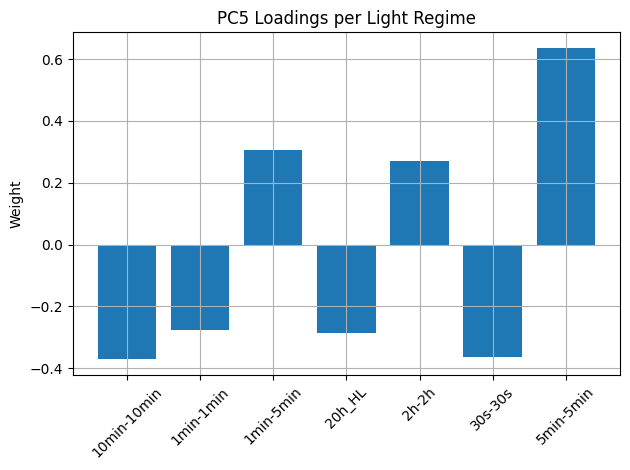

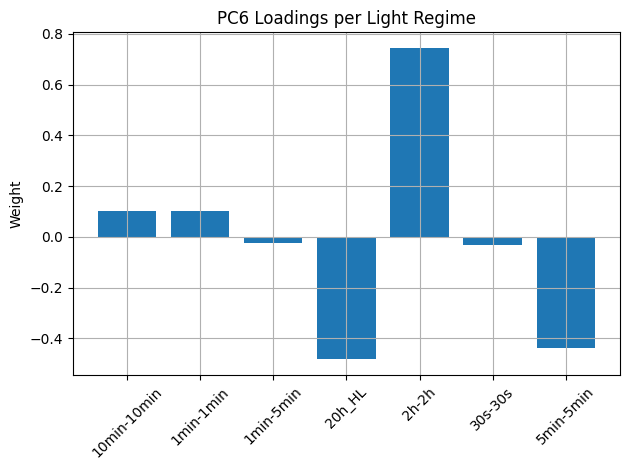

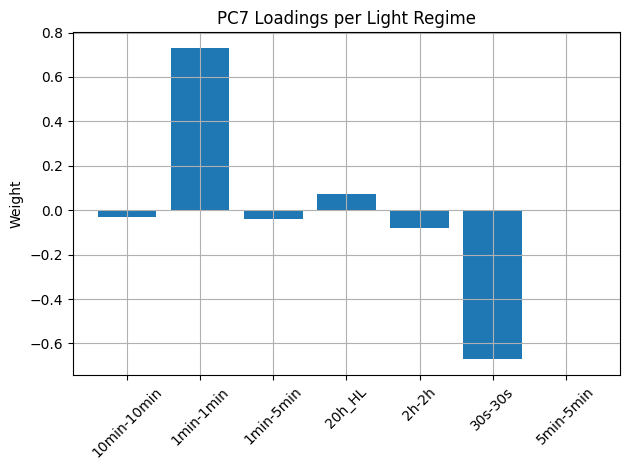

In [120]:
## histogram of loadings for a given PC
ordered_regimes = [
    '20h_HL', '2h-2h', '10min-10min',
    '5min-5min', '1min-5min', '1min-1min', '30s-30s'
]
n_pcs = 7 # Change to 1, 2, etc. for PC2, PC3...
for pc_num in range(1, n_pcs+1):
    plt.bar(Y.columns, pca.components_[pc_num-1])  # Loadings of PC1
    plt.title(f'PC{pc_num} Loadings per Light Regime')
    plt.ylabel("Weight")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()

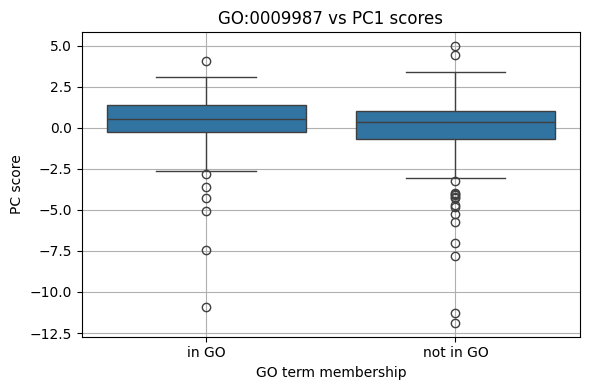

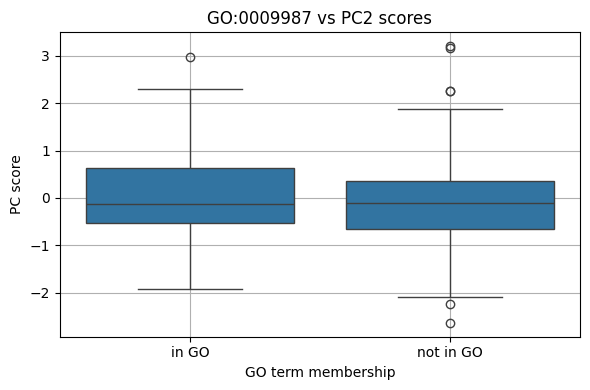

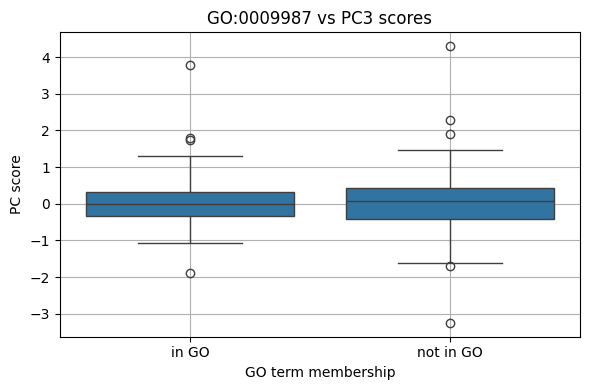

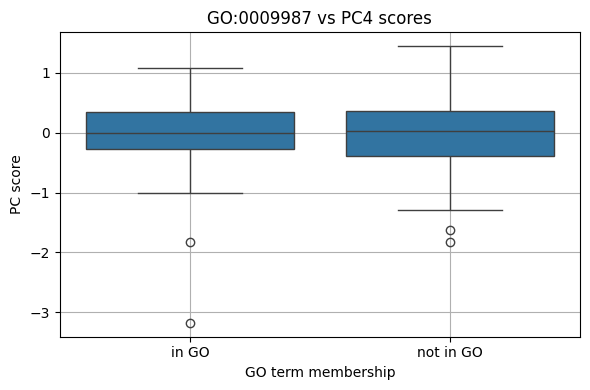

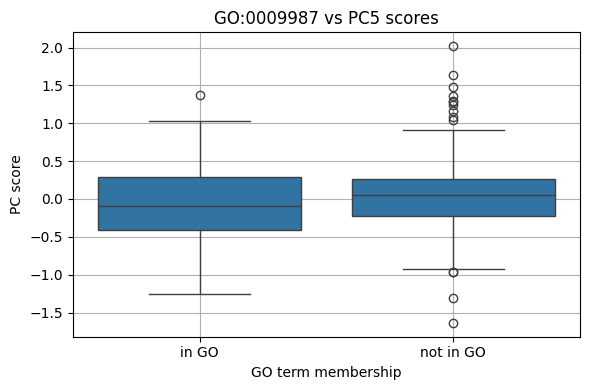

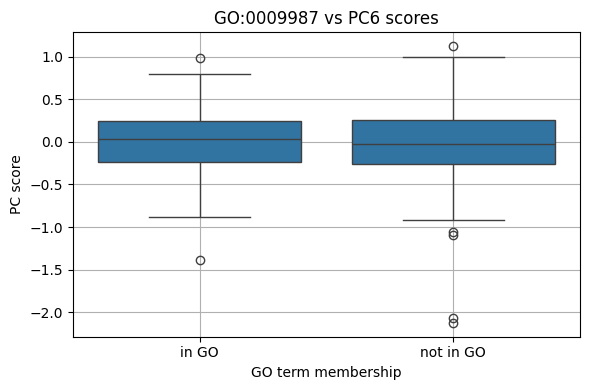

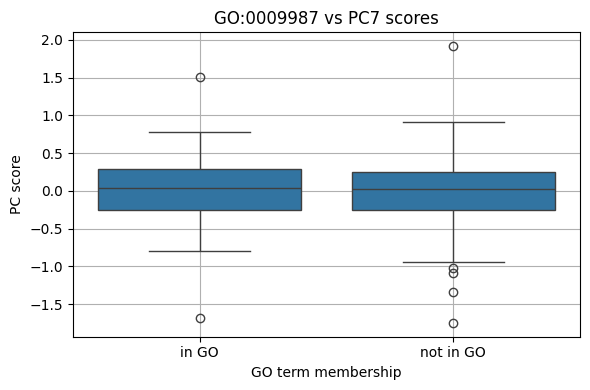

In [158]:
# Merge PC scores with GO annotations
X_go= X
df = PC_df.merge(X_go, left_index=True, right_index=True)

# Pick the PC and GO term
pc_cols = [f'PC{i}' for i in range(1,8)]
go_term = 'GO:0009987'

# Plot
import seaborn as sns
import matplotlib.pyplot as plt
for pc_col in pc_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=df[go_term].map({0: 'not in GO', 1: 'in GO'}), y=pc_col)
    plt.title(f'{go_term} vs {pc_col} scores')
    plt.ylabel('PC score')
    plt.xlabel('GO term membership')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
